# 02 · Reliability (W1) — inter-annotator agreement

Cohen's κ over the predecessor's interannotator files (opus vs gpt5, condition C).
**Backs:** `docs/safety/w1-codebook.md`, `docs/communication/w1-codebook.md`, `docs/reference/invisible-failures-summary.md`, `docs/methodology/{triggers_and_covariates,derivation}.md`.
**Script:** `predecessor_agreement.{signal_kappa, archetype_kappa, failure_visibility_kappa}()`.

In [1]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT/"src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT/"src"))
import pandas as pd
pd.set_option("display.max_rows", 120)
print("repo root:", ROOT)

repo root: /data/wang/junh/githubs/human-agent-coupling-errors


## C. Signal κ (the reliability spine)
Doc claim: low-reliability internal-state signals — `silent_assumption` **0.20**, `generate_without_clarifying` **0.21**, `problem_surfaced` **0.07**; high-reliability surface signals — `ai_acknowledges_correction` **0.81**, `user_positive_feedback` **0.81**.

In [2]:
import predecessor_agreement as pa
sk = pa.signal_kappa()
print(f"{sk['n_signals']} signals | median κ {sk['median_kappa']:.2f} | tiers {sk['tiers']}")
sig_df = pd.DataFrame(sk["rows"])
sig_df

60 signals | median κ 0.50 | tiers {'ge_0.6': 18, '0.4_0.6': 28, 'lt_0.4': 14}


,signal,kappa,prev,opus_prev,gpt5_prev
0,ai_acknowledges_correction,0.808666,0.04200,0.0448,0.0392
1,user_positive_feedback,0.806690,0.00520,0.0055,0.0049
2,ai_malfunction,0.784148,0.02785,0.0331,0.0226
3,ai_refuses_or_declines,0.760177,0.03745,0.0420,0.0329
4,ai_asserts_knowledge_limit,0.722255,0.09040,0.0755,0.1053
5,ai_provides_step_by_step,0.722161,0.13950,0.1626,0.1164
6,user_abandons_thread,0.720680,0.08060,0.0828,0.0784
7,adaptation,0.714141,0.12255,0.1288,0.1163
8,ai_provides_caveats,0.707722,0.16160,0.1630,0.1602
9,ai_asked_clarifying_question,0.703604,0.04220,0.0504,0.0340


In [3]:
# the signals the docs single out
key = ["silent_assumption","generate_without_clarifying","problem_surfaced","ai_self_contradiction",
       "ai_acknowledges_correction","user_positive_feedback","ai_refuses_or_declines"]
sig_df.set_index("signal").reindex(key)[["kappa","prev"]]

,kappa,prev
signal,,
silent_assumption,0.198690,0.12875
generate_without_clarifying,0.206015,0.34365
problem_surfaced,0.067407,0.03695
ai_self_contradiction,0.096303,0.01315
ai_acknowledges_correction,0.808666,0.04200
user_positive_feedback,0.806690,0.00520
ai_refuses_or_declines,0.760177,0.03745


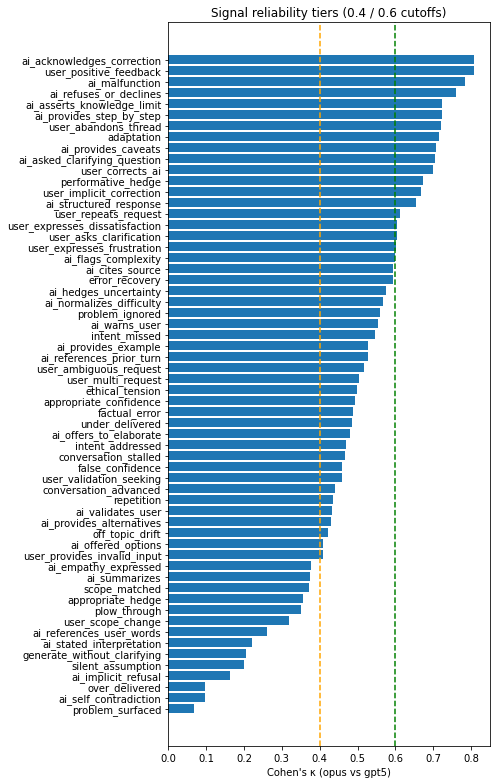

In [4]:
import matplotlib.pyplot as plt
d = sig_df.sort_values("kappa")
fig, ax = plt.subplots(figsize=(7, 11))
ax.barh(d["signal"], d["kappa"])
ax.axvline(0.6, ls="--", c="green"); ax.axvline(0.4, ls="--", c="orange")
ax.set_xlabel("Cohen's κ (opus vs gpt5)"); ax.set_title("Signal reliability tiers (0.4 / 0.6 cutoffs)")
plt.tight_layout(); plt.show()

## B. Archetype κ — condition C
Doc claim: MACRO **0.55**, MICRO **0.81**; `confidence_trap` **0.92**, `walkaway` **0.81**, `mystery_failure` **0.06**.

In [5]:
ak = pa.archetype_kappa("C")
print(f"MACRO {ak['macro']:.2f} | MICRO {ak['micro']:.2f} (agreement {ak['micro_agreement']:.1%})")
pd.DataFrame(ak["per_archetype"])

MACRO 0.55 | MICRO 0.81 (agreement 94.6%)


,archetype,kappa,agreement,opus_prev,gpt5_prev
0,none,0.857167,0.9318,0.4190,0.3610
1,the_confidence_trap,0.922873,0.9744,0.2089,0.2113
2,the_contradiction_unravel,0.541307,0.9923,0.0046,0.0123
3,the_death_spiral,0.803796,0.9866,0.0343,0.0365
4,the_drift,0.321379,0.9429,0.0209,0.0660
5,the_mystery_failure,0.055188,0.9932,0.0002,0.0070
6,the_partial_recovery,0.429365,0.8439,0.0780,0.2317
7,the_silent_mismatch,0.731549,0.8856,0.3204,0.2944
8,the_visible,0.000000,0.9999,0.0000,0.0001
9,the_walkaway,0.811784,0.9072,0.5343,0.6013


## A. failure_visibility κ across conditions A/B/C
Doc claim: condition A (transcript-only) ≈ **0.45**; condition C (signals-only) ≈ **0.81–0.83** — the 100K release uses condition C.

In [6]:
pd.DataFrame(pa.failure_visibility_kappa())

,condition,pair,n,kappa,agreement
0,A,opus/gpt5,9995,0.452362,0.716858
1,B,opus/gpt5,9994,0.685198,0.826996
2,B,opus/sonnet,9951,0.727730,0.846247
3,B,gpt5/sonnet,9952,0.692720,0.830888
4,C,opus/gpt5,10000,0.805357,0.883200
5,C,opus/sonnet,10000,0.831990,0.899600
6,C,gpt5/sonnet,10000,0.827817,0.898700
